In [16]:
# ── Guarda de Dependencias ─────────────────────────────────────────
# Asegura que todos los paquetes requeridos estén instalados en el kernel activo.
# Es seguro re-ejecutar: pip omitirá los paquetes ya instalados.

import importlib, subprocess, sys

_REQUIRED = {
    'numpy': 'numpy',
    'pandas': 'pandas',
    'matplotlib': 'matplotlib',
    'yfinance': 'yfinance',
    'bcchapi': 'bcchapi',
}

_missing = []
for _mod, _pip in _REQUIRED.items():
    try:
        importlib.import_module(_mod)
    except ModuleNotFoundError:
        _missing.append(_pip)

if _missing:
    print(f'Instalando paquetes faltantes: {_missing}')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet'] + _missing)
    print('Hecho. Paquetes instalados exitosamente.')
else:
    print('Todos los paquetes requeridos ya están instalados.')

Todos los paquetes requeridos ya están instalados.


In [17]:
import bcchapi
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import yfinance as yf

siete = bcchapi.Siete("luispino.2e@gmail.com", "Kirigami1@")

# Ejercicio 1 PIB real por región y actividad económica

Utilice la API de datos del Banco Central de Chile para obtener los datos del PIB 2025
(a precios del año anterior encadenado) por regiones, realice un gráfico de pie e interprete.
Luego, seleccione 2 regiones y para ellas muestre la desagregación por actividad económica
indicando cuáles son los principales aportes en cada una de esas regiones.

In [18]:
series_regiones = {
    "Región Metropolitana": "F035.PIB.FLU.R.CLP.2018.Z.Z.Z.13.0.T",
    "Región de Antofagasta": "F035.PIB.FLU.R.CLP.2018.Z.Z.Z.02.0.T",
    "Región de Valparaíso": "F035.PIB.FLU.R.CLP.2018.Z.Z.Z.05.0.T",
    "Región de Arica y Parinacota": "F035.PIB.FLU.R.CLP.2018.Z.Z.Z.15.0.T",
    "Región de Tarapacá": "F035.PIB.FLU.R.CLP.2018.Z.Z.Z.01.0.T",
    "Región de Coquimbo": "F035.PIB.FLU.R.CLP.2018.Z.Z.Z.04.0.T",
    "Región de Atacama": "F035.PIB.FLU.R.CLP.2018.Z.Z.Z.03.0.T",
    "Región de Libertador General Bernardo O'Higgins": "F035.PIB.FLU.R.CLP.2018.Z.Z.Z.06.0.T",
    "Región del Maule": "F035.PIB.FLU.R.CLP.2018.Z.Z.Z.07.0.T",
    "Región del Ñuble": "F035.PIB.FLU.R.CLP.2018.Z.Z.Z.16.0.T",
    "Región del Biobío": "F035.PIB.FLU.R.CLP.2018.Z.Z.Z.08.0.T",
    "Región de la Araucanía": "F035.PIB.FLU.R.CLP.2018.Z.Z.Z.09.0.T",
    "Región de los Ríos": "F035.PIB.FLU.R.CLP.2018.Z.Z.Z.14.0.T",
    "Región de los Lagos": "F035.PIB.FLU.R.CLP.2018.Z.Z.Z.10.0.T",
    "Región de Aysén del General Carlos Ibáñez del Campo": "F035.PIB.FLU.R.CLP.2018.Z.Z.Z.11.0.T",
    "Región de Magallanes y de la Antártica Chilena": "F035.PIB.FLU.R.CLP.2018.Z.Z.Z.12.0.T",
}

try:
    pib_2025 = siete.cuadro(
        series=[series_regiones[region] for region in series_regiones],
        nombres=[region for region in series_regiones],
        desde="2025-01-01",
        hasta="2025-12-31"
    )
    
    print("Datos del PIB 2025 descargados")
    
except Exception as e:
    print(f"Error: {e}")

Datos del PIB 2025 descargados


In [19]:
display(pib_2025)

,Región Metropolitana,Región de Antofagasta,Región de Valparaíso,Región de Arica y Parinacota,Región de Tarapacá,Región de Coquimbo,Región de Atacama,Región de Libertador General Bernardo O'Higgins,Región del Maule,Región del Ñuble,Región del Biobío,Región de la Araucanía,Región de los Ríos,Región de los Lagos,Región de Aysén del General Carlos Ibáñez del Campo,Región de Magallanes y de la Antártica Chilena
2025-01-01,21609.371743,4154.891438,3916.272356,408.311578,1101.235858,1612.529407,1099.019417,2399.905682,2197.016141,849.087156,3388.886488,1709.898717,720.584336,1868.023134,304.117584,544.076757
2025-04-01,21869.638788,4263.261369,3934.640569,410.327762,1234.779457,1637.088763,1110.215193,2042.702693,2112.174436,812.243706,3437.157821,1563.882948,727.987033,1923.277072,341.746120,514.720145
2025-07-01,21630.399431,4394.866057,3944.755736,417.302993,1219.204295,1588.164481,1158.901225,1771.352354,1729.598103,739.956438,3173.023048,1500.319917,681.496741,1792.828466,370.938584,515.658310


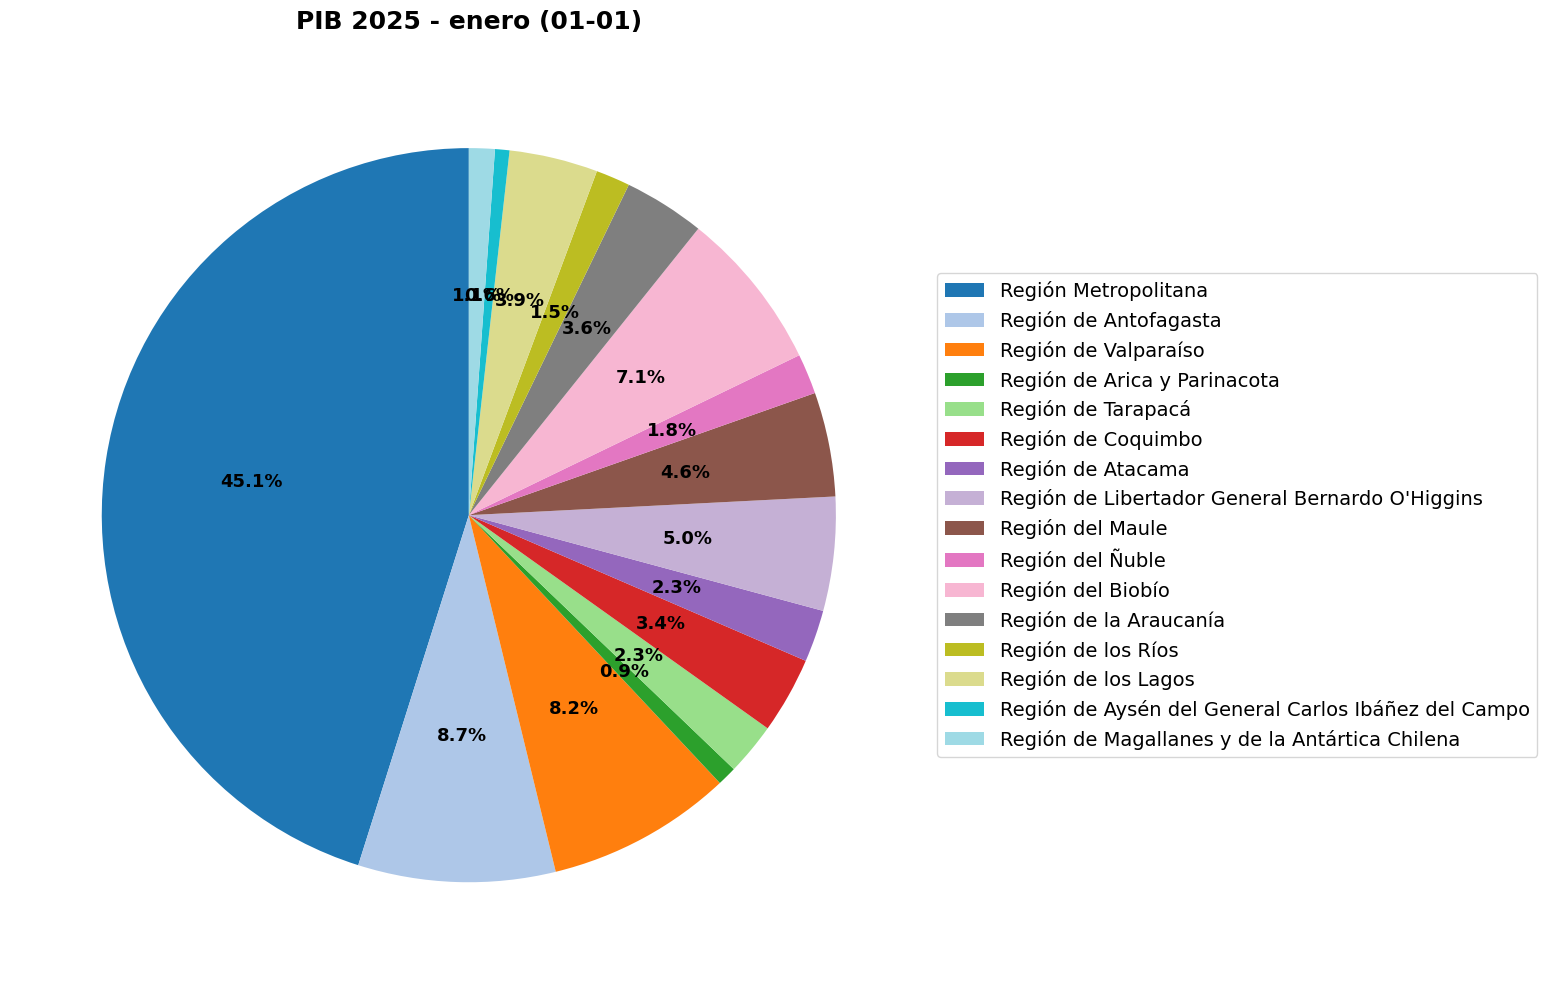

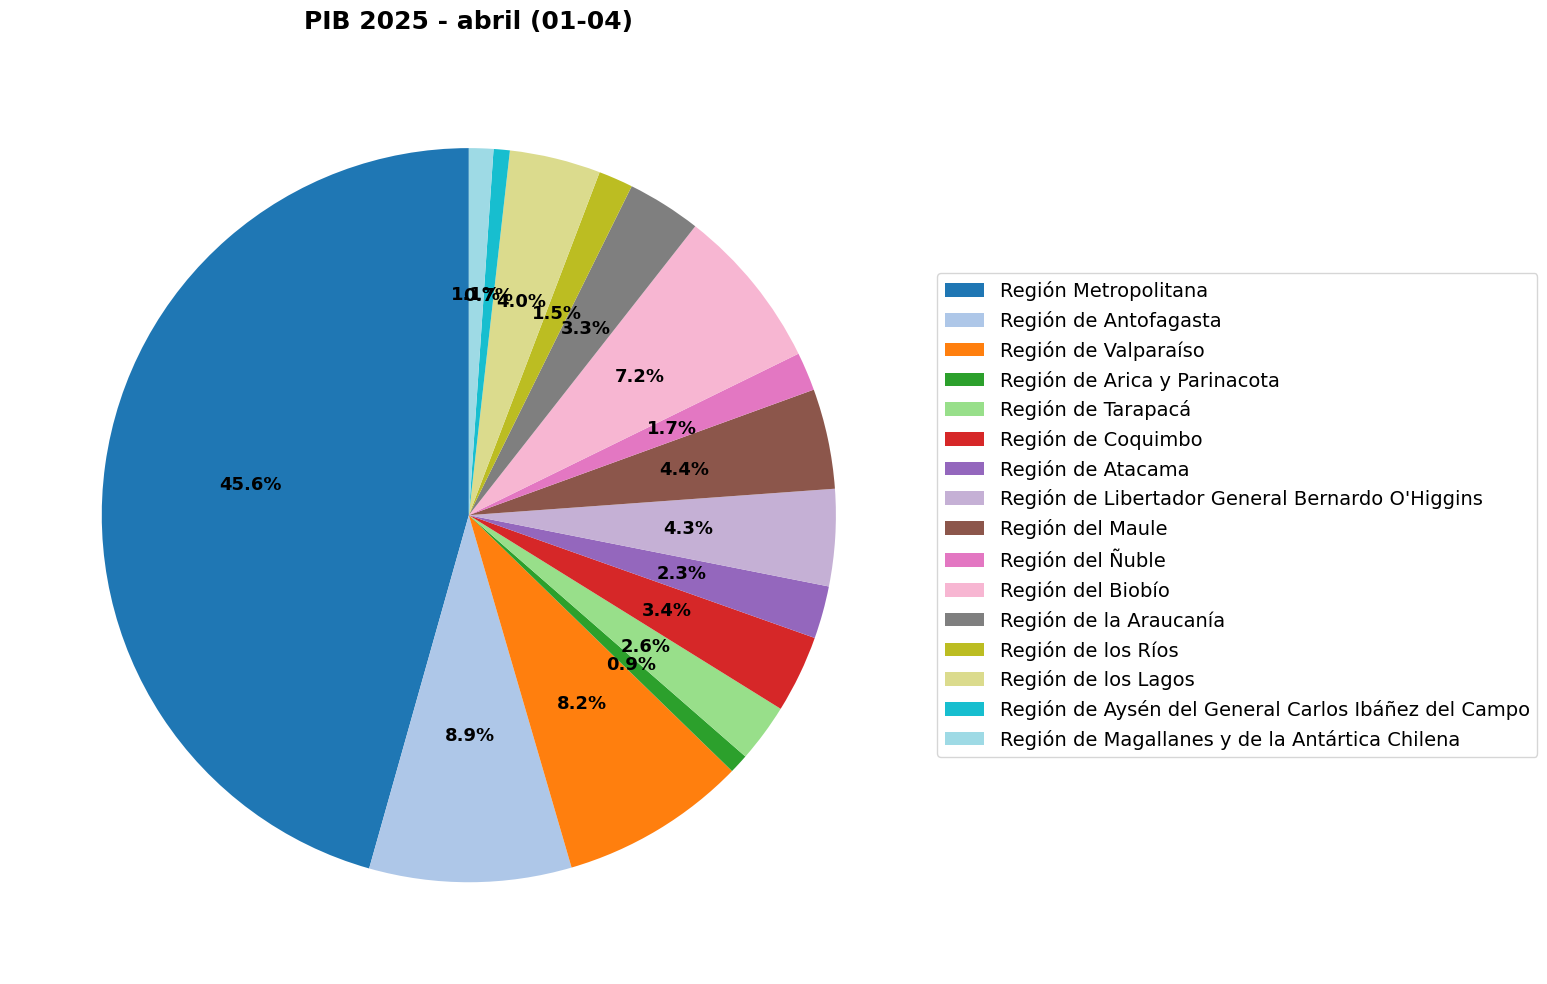

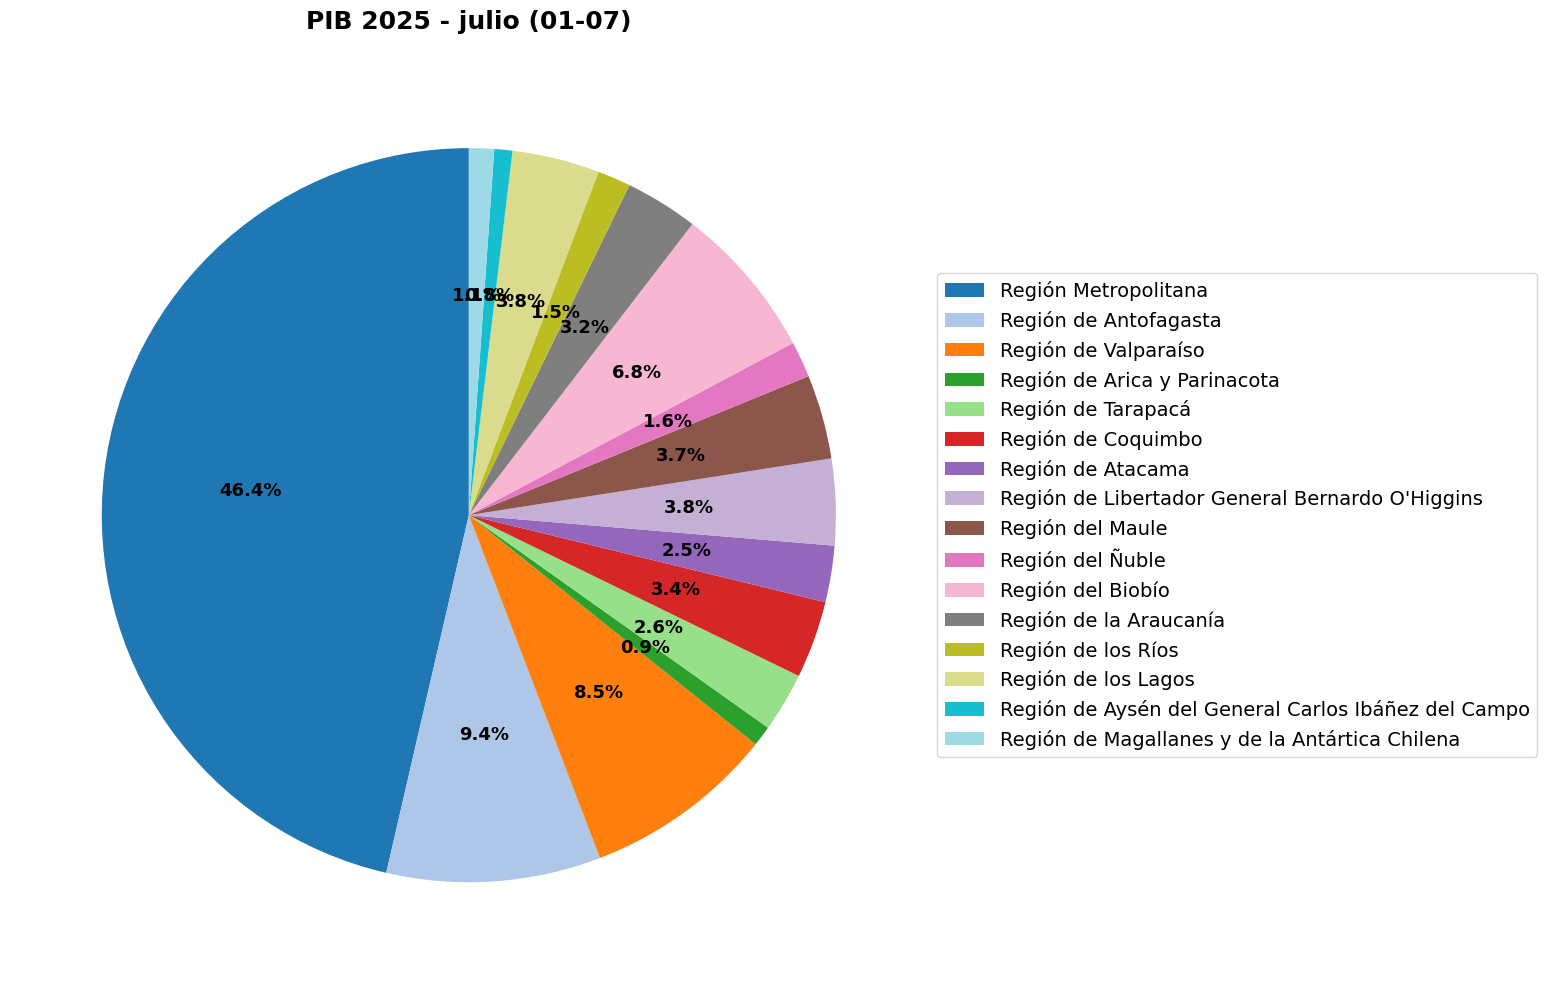

In [52]:
def graficar_pie_pib(serie, titulo):
    fig, ax = plt.subplots(figsize=(14, 10))
    colors = plt.cm.tab20(np.linspace(0, 1, len(serie)))
    ax.pie(
        serie.values,
        autopct='%1.1f%%',
        startangle=90,
        textprops={'fontsize': 13, 'weight': 'bold'},
        colors=colors
    )
    ax.set_title(titulo, fontsize=18, fontweight='bold', pad=20)
    ax.legend(serie.index, loc='center left', bbox_to_anchor=(1, 0, 0.5, 1), fontsize=14)
    plt.tight_layout()
    plt.show()

graficar_pie_pib(pib_2025.iloc[0], f'PIB 2025 - {pib_2025.index[0].strftime("%B (%d-%m)")}')
graficar_pie_pib(pib_2025.iloc[1], f'PIB 2025 - {pib_2025.index[1].strftime("%B (%d-%m)")}')
graficar_pie_pib(pib_2025.iloc[2], f'PIB 2025 - {pib_2025.index[2].strftime("%B (%d-%m)")}')

## Interpretación

**Concentración del PIB en la Región Metropolitana**
La Región Metropolitana cuenta con aproximadamente el 45-46% del PIB nacional. Esta cifra refleja la alta centralización económica alrededor de Santiago.

**Segundas regiones de importancia**
- **Región de Antofagasta** (8.7%-9.4%): Tuvo un ligero aumento de enero a julio.
- **Región de Valparaíso** (8.2%-8.5%): Su comportamiento es relativamente estable.

**Estabilidad Trimestral**
La distribución regional del PIB es muy estable, con variaciones menores de 0.5%. Esto sugiere que no hubo cambios estructurales significativos en la composición económica regional durante este período.

**Implicaciones económicas**
- La fuerte concentración en la Región Metropolitana implica dependencia económica de Santiago y sus alrededores.
- Las regiones del norte tienen participación relevante debido a que son sectores mineros.
- Muchas regiones del sur y centro muestran baja participación, lo que implica un bajo o menor desarrollo económico relativo, con excepción de regiones agrícolas e industriales.

# Ejercicio 2 PIB Nominal y real
A partir de la siguiente tabla calcule lo el PIB nominal y real (con base año 0) de cada
año, y calcule la tasa de crecimiento.

In [21]:
data = {
    'Año': [0,0,0,0, 1,1,1,1, 2,2,2,2],
    'Bien': ['Pan','Vino','Autos','Cobre']*3,
    'Cantidad': [2,3,2,4, 3,4,4,8, 5,3,3,9],
    'Precio': [3,5,10,7, 4,5,14,20, 5,7,16,22]
}

df = pd.DataFrame(data)
display(df)
precios_base = df[df['Año'] == 0][['Bien','Precio']].set_index('Bien')['Precio']

df['PIB_nominal'] = df['Cantidad'] * df['Precio'] 
df['Precio_base_año0'] = df['Bien'].map(precios_base)
df['PIB_real'] = df['Cantidad'] * df['Precio_base_año0']

resumen = df.groupby('Año')[['PIB_nominal','PIB_real']].sum()
resumen['Crecimiento_nominal(%)'] = resumen['PIB_nominal'].pct_change()*100 # pct_change() = Tasa de crecimiento (final-inicial)/inicial*100
resumen['Crecimiento_real(%)'] = resumen['PIB_real'].pct_change()*100
display(resumen)

,Año,Bien,Cantidad,Precio
0,0,Pan,2,3
1,0,Vino,3,5
2,0,Autos,2,10
3,0,Cobre,4,7
4,1,Pan,3,4
5,1,Vino,4,5
6,1,Autos,4,14
7,1,Cobre,8,20
8,2,Pan,5,5
9,2,Vino,3,7


,PIB_nominal,PIB_real,Crecimiento_nominal(%),Crecimiento_real(%)
Año,,,,
0,69,69,NaN,NaN
1,248,125,259.420290,81.15942
2,292,123,17.741935,-1.60000


Mientras el PIB nominal presenta un crecimiento considerable, el PIB real muestra un aumento mucho más pequeño e incluso se vuelve negativo en el año 2. Esta diferencia muestra la presencia de presiones inflacionarias dentro de la economía, ya que el crecimiento del PIB Nominal se explica principalmente por los aumentos de precios y no por un crecimiento en las cantidades producidas. En términos económicos, esto implica que el desempeño de la actividad productiva podría estar siendo menor del deseado. La caída del PIB real en el último período sugiere una posible desaceleración económica, lo cual podría traducirse en menores niveles de bienestar y un estancamiento productivo.

# Ejercicio 3 Canasta IPC
Realice un gráfico de pie con las 13 divisiones de la canasta IPC 2026, luego seleccione 2
de ellas y explique la incidencia que tuvieron en la inflación de febrero 2026 (Boletín IPC).

In [22]:
ipc_data = {
    'División': [
        'Alimentos y bebidas no alcohólicas',
        'Bebidas alcohólicas y tabaco',
        'Vestuario y calzado',
        'Vivienda y servicios básicos',
        'Equipamiento y mantenimiento del hogar',
        'Salud',
        'Transporte',
        'Información y comunicación',
        'Recreación, deportes y cultura',
        'Educación',
        'Restaurantes y alojamiento',
        'Seguros y servicios financieros',
        'Bienes y servicios diversos'
    ],
    'Ponderación': [22.15348, 3.68125, 2.90408, 16.76733, 3.18253, 8.21206, 13.45108, 6.64634, 4.75354, 4.19831, 6.22047, 6.35266, 3.72905],
    'Índice': [110.94, 107.95, 93.97, 119.89, 103.19, 111.64, 101.36, 102.11, 106.09, 113.17, 118.75, 117.23, 108.00],
    'Variación_Mensual': [0.2, -0.9, 2.3, -0.4, 0.6, 0.4, 0.1, -0.4, -0.1, 0.0, -0.1, -0.4, -0.5],
    'Incidencia_Mensual': [0.6, -0.034, 0.066, -0.1, 0.014, 0.037, 0.016, -0.022, -0.005, 0.001, -0.005, -0.022, -0.019],
    'Variación_12meses': [4.2, 2.2, 4.5, 3.1, 1.2, 5.2, -2.0, 4.8, 1.9, 5.5, 6.0, 3.6, 2.1],
    'Incidencia_12meses': [0.918, 0.081, 0.131, 0.559, 0.069, 0.420, -0.262, -0.028, 0.086, 0.230, 0.390, 0.230, 0.078]
}

df_ipc = pd.DataFrame(ipc_data)
display(df_ipc)

,División,Ponderación,Índice,Variación_Mensual,Incidencia_Mensual,Variación_12meses,Incidencia_12meses
0,Alimentos y bebidas no alcohólicas,22.15348,110.94,0.2,0.600,4.2,0.918
1,Bebidas alcohólicas y tabaco,3.68125,107.95,-0.9,-0.034,2.2,0.081
2,Vestuario y calzado,2.90408,93.97,2.3,0.066,4.5,0.131
3,Vivienda y servicios básicos,16.76733,119.89,-0.4,-0.100,3.1,0.559
4,Equipamiento y mantenimiento del hogar,3.18253,103.19,0.6,0.014,1.2,0.069
5,Salud,8.21206,111.64,0.4,0.037,5.2,0.420
6,Transporte,13.45108,101.36,0.1,0.016,-2.0,-0.262
7,Información y comunicación,6.64634,102.11,-0.4,-0.022,4.8,-0.028
8,"Recreación, deportes y cultura",4.75354,106.09,-0.1,-0.005,1.9,0.086
9,Educación,4.19831,113.17,0.0,0.001,5.5,0.230


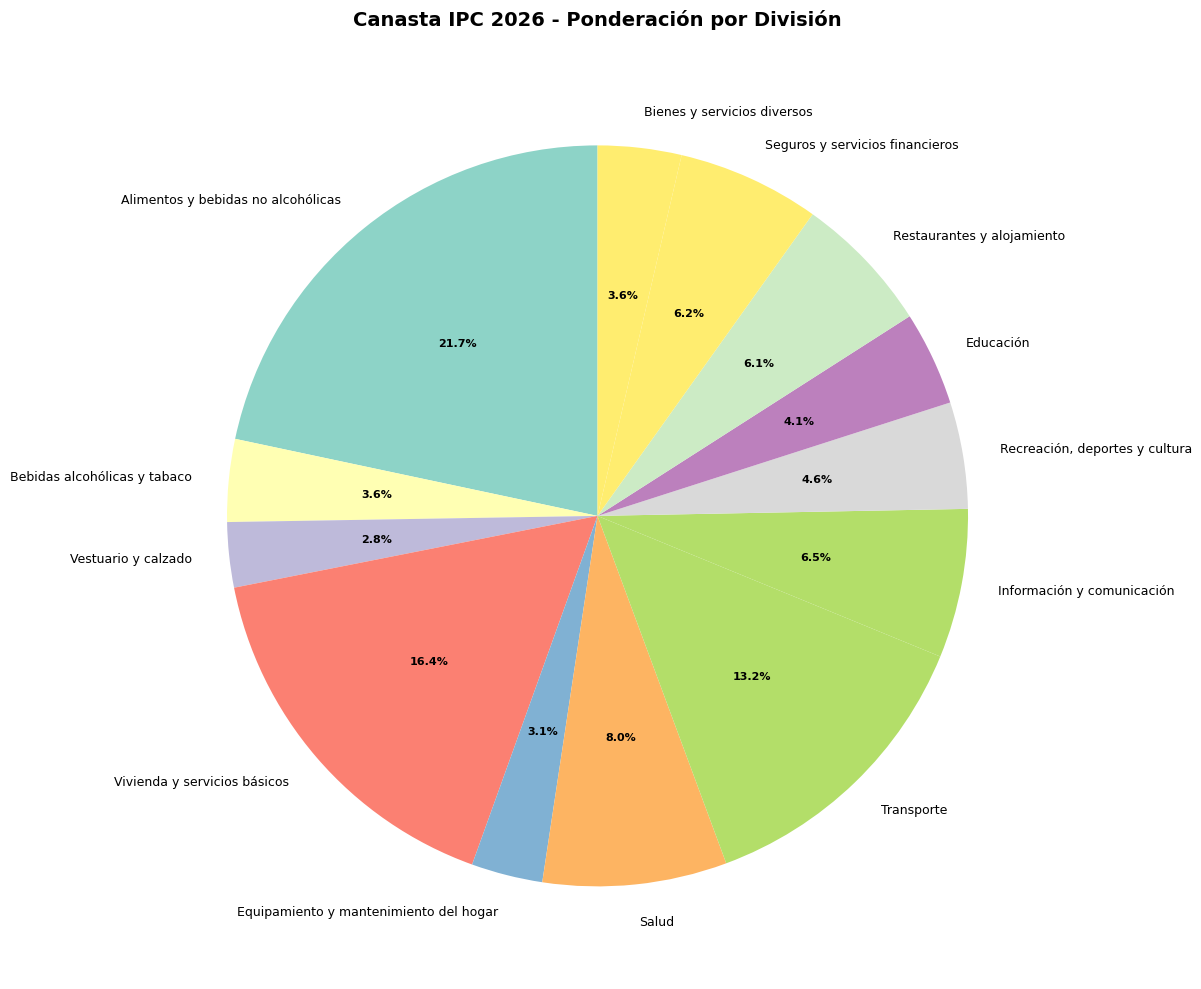

Ponderación total: 102.25218000000002


In [23]:
fig, ax = plt.subplots(figsize=(14, 10))
colors = plt.cm.Set3(np.linspace(0, 1, len(df_ipc)))

wedges, texts, autotexts = ax.pie(
    df_ipc['Ponderación'],
    labels=df_ipc['División'],
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 9},
    colors=colors
)

for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(8)

ax.set_title('Canasta IPC 2026 - Ponderación por División', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("Ponderación total:", df_ipc['Ponderación'].sum())

ANÁLISIS DE INCIDENCIA EN LA INFLACIÓN - FEBRERO 2026

1. ALIMENTOS Y BEBIDAS NO ALCOHÓLICAS
--------------------------------------------------------------------------------
   Ponderación en canasta: 22.15%
   Variación mensual: +0.2%
   Incidencia mensual: +0.600 pp
   Variación 12 meses: +4.2%
   Incidencia acumulada 12 meses: +0.918 pp

3. VESTUARIO Y CALZADO
--------------------------------------------------------------------------------
   Ponderación en canasta: 2.90%
   Variación mensual: +2.3%
   Incidencia mensual: +0.066 pp
   Variación 12 meses: +4.5%
   Incidencia acumulada 12 meses: +0.131 pp


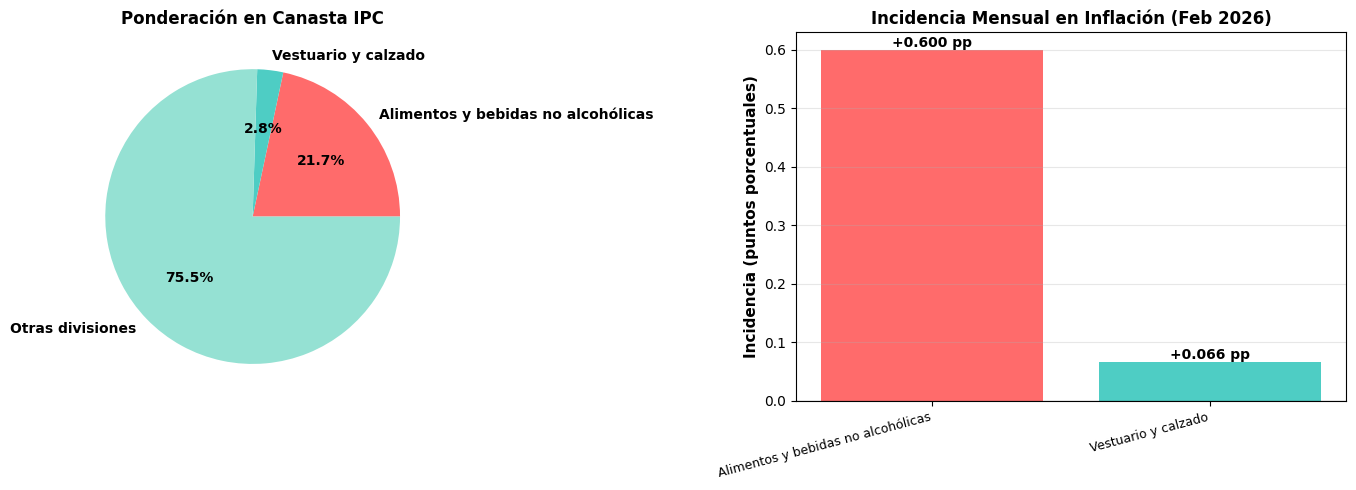


CONTRIBUCIÓN TOTAL A LA INFLACIÓN

Incidencia de las 2 divisiones seleccionadas: +0.666 pp
Incidencia total (todas las divisiones): +0.527 pp
Contribución % de estas 2 divisiones: 126.4%


In [24]:
top_divisions = df_ipc.nlargest(2, 'Incidencia_Mensual')

print("=" * 80)
print("ANÁLISIS DE INCIDENCIA EN LA INFLACIÓN - FEBRERO 2026")
print("=" * 80)

for idx, row in top_divisions.iterrows():
    print(f"\n{idx + 1}. {row['División'].upper()}")
    print("-" * 80)
    print(f"   Ponderación en canasta: {row['Ponderación']:.2f}%")
    print(f"   Variación mensual: {row['Variación_Mensual']:+.1f}%")
    print(f"   Incidencia mensual: {row['Incidencia_Mensual']:+.3f} pp")
    print(f"   Variación 12 meses: {row['Variación_12meses']:+.1f}%")
    print(f"   Incidencia acumulada 12 meses: {row['Incidencia_12meses']:+.3f} pp")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

otras = df_ipc[~df_ipc.index.isin(top_divisions.index)]['Ponderación'].sum()
ponderacion_compare = pd.Series({
    top_divisions.iloc[0]['División']: top_divisions.iloc[0]['Ponderación'],
    top_divisions.iloc[1]['División']: top_divisions.iloc[1]['Ponderación'],
    'Otras divisiones': otras
})

colors_comp = ['#FF6B6B', '#4ECDC4', '#95E1D3']
axes[0].pie(ponderacion_compare, labels=ponderacion_compare.index, autopct='%1.1f%%',
            colors=colors_comp, textprops={'fontsize': 10, 'weight': 'bold'})
axes[0].set_title('Ponderación en Canasta IPC', fontsize=12, fontweight='bold')

divisiones_names = top_divisions['División'].values
incidencia_values = top_divisions['Incidencia_Mensual'].values

bars = axes[1].bar(range(len(divisiones_names)), incidencia_values, color=['#FF6B6B', '#4ECDC4'])
axes[1].set_ylabel('Incidencia (puntos porcentuales)', fontsize=11, fontweight='bold')
axes[1].set_title('Incidencia Mensual en Inflación (Feb 2026)', fontsize=12, fontweight='bold')
axes[1].set_xticks(range(len(divisiones_names)))
axes[1].set_xticklabels(divisiones_names, rotation=15, ha='right', fontsize=9)
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.8)
axes[1].grid(axis='y', alpha=0.3)

for i, (bar, val) in enumerate(zip(bars, incidencia_values)):
    axes[1].text(bar.get_x() + bar.get_width()/2, val, f'{val:+.3f} pp',
                ha='center', va='bottom' if val > 0 else 'top', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("CONTRIBUCIÓN TOTAL A LA INFLACIÓN")
print("=" * 80)
print(f"\nIncidencia de las 2 divisiones seleccionadas: {top_divisions['Incidencia_Mensual'].sum():+.3f} pp")
print(f"Incidencia total (todas las divisiones): {df_ipc['Incidencia_Mensual'].sum():+.3f} pp")
print(f"Contribución % de estas 2 divisiones: {(top_divisions['Incidencia_Mensual'].sum() / df_ipc['Incidencia_Mensual'].sum() * 100):.1f}%")

## Interpretación de la Incidencia Inflacionaria - Febrero 2026

### 1. **Alimentos y Bebidas No Alcohólicas** 
- **Ponderación:** 22.15% - Es la división más importante en la canasta IPC, representando más de 1/5 del gasto de los consumidores.
- **Variación mensual:** +0.2% - Aumento en precios durante febrero 2026.
- **Incidencia mensual:** +0.6 pp (puntos porcentuales) - Mayor contribuidor individual a la inflación de febrero.
- **Interpretación económica:** Los alimentos son un bien de consumo esencial con alta frecuencia de compra. Su aumento de precios directamente impacta el poder adquisitivo de las familias chilenas. Esto sugiere presiones inflacionarias en el sector agrícola o en los costos de distribución. Este es el factor más relevante explica la mayor parte del incremento inflacionario mensual.

### 2. **Vivienda y Servicios Básicos**
- **Ponderación:** 16.77% - Segunda división más importante después de alimentos.
- **Variación mensual:** -0.4% - Reducción en el índice durante febrero.
- **Incidencia mensual:** -0.1 pp - Efecto deflacionario, pero menor y negativo.
- **Interpretación económica:** A pesar de su importante ponderación, los servicios de vivienda (agua, luz, gas) experimentaron una caída en febrero. Esto puede deberse a factores estacionales como menor consumo de energía o políticas regulatorias que contuvieron aumentos tarifarios.

### Conclusiones Principales:

1. **Composición de la Inflación:** La inflación de febrero 2026 estuvo impulsada principalmente por el aumento en precios de alimentos (+0.6 pp), mientras que la vivienda y servicios básicos actuó como moderador (-0.1 pp).

2. **Balances Parciales:** Aunque la vivienda ayudó a moderar la inflación, su contribución fue menor, sugiriendo que sin este efecto compensatorio, la inflación mensual hubiera sido mayor.

# Ejercicio 4 Inflación
Considere una economía en la cual se tiene el siguiente detalle de los bienes producidos
o importados por sus habitantes.

In [25]:
data = {
    'Año': [0,0,0, 1,1,1],
    'Bien': ['Pan','Vino','Autos']*2,
    'Cantidad': [2,3,2, 3,4,4],
    'Precio': [3,5,10, 4,5,14]
}

df = pd.DataFrame(data)
display(df)

precios_base = df[df['Año']==0][['Bien','Precio']].set_index('Bien')['Precio']

df['Gasto'] = df['Precio'] * df['Cantidad']
df['Total_gasto'] = df.groupby('Año')['Gasto'].transform('sum')
df['theta'] = df['Gasto'] / df['Total_gasto']

# peso sobre el IPC
df['peso'] = df['Precio'] / df['Bien'].map(precios_base)

# IPC
df['IPC_term'] = df['theta'] * df['peso']

display(df)

ipc = df.groupby('Año')['IPC_term'].sum() * 100

print("IPC por año:")
print(ipc)

# Inflación
inflacion = ipc.pct_change() * 100
print("\nInflación:")
print(inflacion.iloc[1])  

,Año,Bien,Cantidad,Precio
0,0,Pan,2,3
1,0,Vino,3,5
2,0,Autos,2,10
3,1,Pan,3,4
4,1,Vino,4,5
5,1,Autos,4,14


,Año,Bien,Cantidad,Precio,Gasto,Total_gasto,theta,peso,IPC_term
0,0,Pan,2,3,6,41,0.146341,1.000000,0.146341
1,0,Vino,3,5,15,41,0.365854,1.000000,0.365854
2,0,Autos,2,10,20,41,0.487805,1.000000,0.487805
3,1,Pan,3,4,12,88,0.136364,1.333333,0.181818
4,1,Vino,4,5,20,88,0.227273,1.000000,0.227273
5,1,Autos,4,14,56,88,0.636364,1.400000,0.890909


IPC por año:
Año
0    100.0
1    130.0
Name: IPC_term, dtype: float64

Inflación:
29.999999999999982


EL calculo del ipc resulta en una inflación de aproximadamente 30%, lo que es un valor bastante alto en terminos de macroeconomia. Este resultado sedebe principalmente al incremento en el precio de los autos, un bien que además posee una alta ponderación dentro de la canasta de consumo. Esto nos muestra que la inflación no depende únicamente de la variación de precios (como vimos en el ejercicio 2), sino también del gasto de los consumidores, ya que aquellos bienes con mayor peso afectan de manera más significativa al IPC. Desde una perspectiva económica, una inflación de esta magnitud genera efectos adversos importantes, como la pérdida del poder adquisitivo y un aumento en la incertidumbre. Del mismo modo, este escenario podría motivar la implementación de politicas monetarias contractivas por parte del banco central, como el aumento de tasas de interés, con el objetivo de contener las presiones inflacionarias.

# Ejercicio 5 Mercado del dinero
Obtenga, a través de la API de yfinance, el tipo de cambio CLP/USD de los últimos 5
años. Junto con esto, obtenga la TPM de la API del banco central. Obtenga la correlación
y grafique ambos. A partir de esto interprete y explique la relación entre las dos.


- a) Muestre en un mismo gráfico ambas series y obtenga la correlación entre las 2.
- b) Añada al análisis el precio del cobre en el mismo periodo, también obtenido de yfinance,
y obtenga las correlaciones.
- c) Interprete sus resultados, y explique una posible relación entre las 3.

In [46]:
end = pd.Timestamp.today().normalize()
start = end - pd.DateOffset(years=5)

#CLP/USD y cobre
clp_raw = yf.download("clp=x", start=start, end=end, progress=False, auto_adjust=False)
cobre_raw = yf.download("hg=f", start=start, end=end, progress=False, auto_adjust=False)

def extraer_close(df_raw):
    if isinstance(df_raw.columns, pd.MultiIndex):
        return df_raw.xs("Close", axis=1, level=0).iloc[:, 0]
    return df_raw["Close"]

clp = extraer_close(clp_raw).rename("CLP_USD")
cobre = extraer_close(cobre_raw).rename("COBRE_USD_LB")

#TPM
tpm = siete.cuadro(
    series=["F022.TPM.TIN.D001.NO.Z.D"],
    nombres=["TPM"],
    desde=start.strftime("%Y-%m-%d"),
    hasta=end.strftime("%Y-%m-%d")
)

df_market = pd.concat([clp, tpm["TPM"], cobre], axis=1, sort=False).dropna()

print(f"Rango usado: {start.date()} a {end.date()}")
display(df_market)

Rango usado: 2021-04-05 a 2026-04-05


,CLP_USD,TPM,COBRE_USD_LB
2021-04-05,716.599976,0.5,4.1490
2021-04-06,721.000000,0.5,4.1265
2021-04-07,717.299988,0.5,4.0640
2021-04-08,713.200012,0.5,4.1035
2021-04-09,707.700012,0.5,4.0505
...,...,...,...
2026-03-27,928.039978,4.5,5.4670
2026-03-30,922.719971,4.5,5.4760
2026-03-31,930.219971,4.5,5.5875
2026-04-01,926.109985,4.5,5.6240


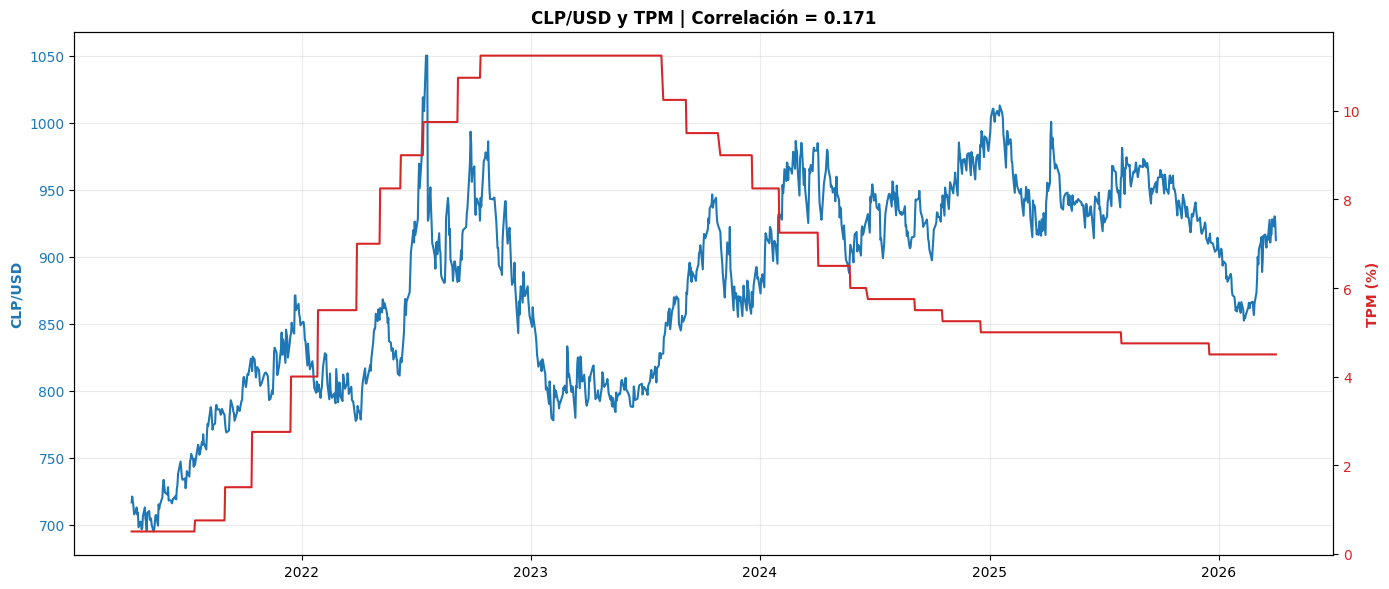


correlaciones


,CLP_USD,TPM,COBRE_USD_LB
CLP_USD,1.000000,0.171202,0.024719
TPM,0.171202,1.000000,-0.561911
COBRE_USD_LB,0.024719,-0.561911,1.000000


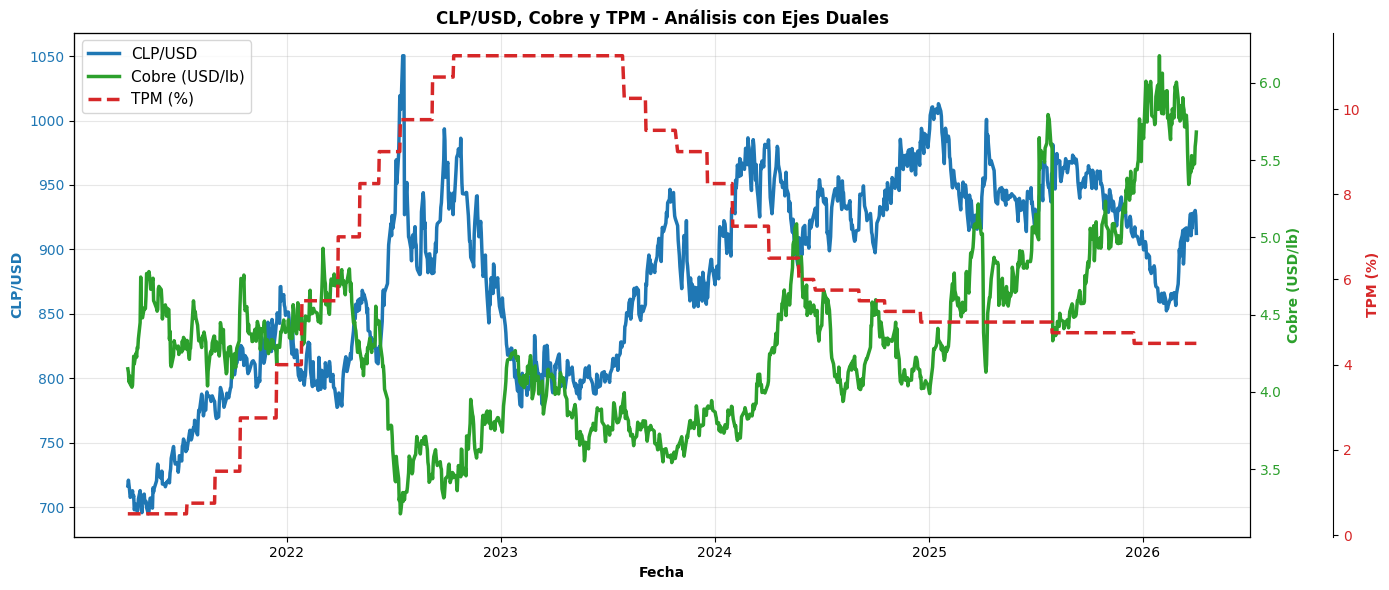


Correlaciones clave:
- Corr(CLP/USD, TPM)   = 0.171
- Corr(CLP/USD, Cobre) = 0.025
- Corr(TPM, Cobre)     = -0.562


In [47]:
# Correlación y gráfico  CLP/USD vs TPM
df_a = df_market[["CLP_USD", "TPM"]].copy()
corr_a = df_a.corr().loc["CLP_USD", "TPM"]

fig, ax1 = plt.subplots(figsize=(14, 6))
ax1.plot(df_a.index, df_a["CLP_USD"], color="tab:blue", label="CLP/USD")
ax1.set_ylabel("CLP/USD", color="tab:blue", fontweight="bold")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
ax2.plot(df_a.index, df_a["TPM"], color="tab:red", label="TPM (%)")
ax2.set_ylabel("TPM (%)", color="tab:red", fontweight="bold")
ax2.tick_params(axis="y", labelcolor="tab:red")

ax1.set_title(f"CLP/USD y TPM | Correlación = {corr_a:.3f}", fontweight="bold")
ax1.grid(alpha=0.25)
fig.tight_layout()
plt.show()

# Añadir cobre y obtener correlaciones entre las 3 series
df_b = df_market[["CLP_USD", "TPM", "COBRE_USD_LB"]].copy()
corr_b = df_b.corr()

print("\ncorrelaciones")
display(corr_b)

# Gráfico conjunto con ejes duales
fig, ax1 = plt.subplots(figsize=(14, 6))

# Eje izquierdo: CLP/USD y Cobre
color1 = 'tab:blue'
ax1.plot(df_b.index, df_b["CLP_USD"], color=color1, label="CLP/USD", linewidth=2.5)
ax1.set_xlabel("Fecha", fontweight="bold")
ax1.set_ylabel("CLP/USD", color=color1, fontweight="bold")
ax1.tick_params(axis="y", labelcolor=color1)
ax1.grid(alpha=0.3)

ax1_twin = ax1.twinx()
color2 = 'tab:green'
ax1_twin.plot(df_b.index, df_b["COBRE_USD_LB"], color=color2, label="Cobre (USD/lb)", linewidth=2.5)
ax1_twin.set_ylabel("Cobre (USD/lb)", color=color2, fontweight="bold")
ax1_twin.tick_params(axis="y", labelcolor=color2)

# Eje derecho (secundario): TPM
ax2 = ax1.twinx()
ax2.spines['right'].set_position(('outward', 60))
color3 = 'tab:red'
ax2.plot(df_b.index, df_b["TPM"], color=color3, label="TPM (%)", linewidth=2.5, linestyle='--')
ax2.set_ylabel("TPM (%)", color=color3, fontweight="bold")
ax2.tick_params(axis="y", labelcolor=color3)

ax1.set_title("CLP/USD, Cobre y TPM - Análisis con Ejes Duales", fontweight="bold", fontsize=12)

# Leyenda combinada
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_twin.get_legend_handles_labels()
lines3, labels3 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2 + lines3, labels1 + labels2 + labels3, loc='upper left', fontsize=11)

fig.tight_layout()
plt.show()

# Resumen numérico para interpretación
print("\nCorrelaciones clave:")
print(f"- Corr(CLP/USD, TPM)   = {corr_b.loc['CLP_USD','TPM']:.3f}")
print(f"- Corr(CLP/USD, Cobre) = {corr_b.loc['CLP_USD','COBRE_USD_LB']:.3f}")
print(f"- Corr(TPM, Cobre)     = {corr_b.loc['TPM','COBRE_USD_LB']:.3f}")

En el tiempo analizado, vimos que la tasa (TPM) subió muchísimo, pasando de 0.5% en 2021 hasta llegar a un tope de casi 10.5% entre 2022 y 2024, para luego bajar al 4.5% en 2026. Esto pasó porque el Banco Central tuvo que reaccionar para frenar las subidas de precios. Al mismo tiempo, el dólar se movió entre los $700 y los $1.050, subiendo mucho (especialmente en 2022-2023) y luego bajando un poco (2024-2026), mientras que el cobre anduvo entre los 3.3 y 6.0 dólares la libra, con una tendencia a subir últimamente.

- **Corr(CLP/USD, TPM) = 0.171:** Relación positiva pero débil, esto nos dice que la TPM no es el único que influye en el tipo de cambio.
- **Corr(CLP/USD, Cobre) = 0.025:** No hay casi ninguna relación directa. Esto indica que el precio del cobre no explica por sí solo cómo se mueve el dólar en el día a día.
- **Corr(TPM, Cobre) = -0.562:** Hay una relación negativa moderada. Esto muestra que cuando el cobre sube en USD la TPM suele bajar y viceversa.

La baja conexión entre el dólar y la tasa sugiere que apesar de que si hay cierta influencia entre ellas, hay mas situaciones, valores o reglas que quen influyen en el tipo de cambio (como pueden ser el precio de otras importaciones).  

La correlación prácticamente nula entre el tipo de cambio y el precio del cobre indica que las variaciones del cobre no se traducen de manera sistemática en movimientos del dólar en Chile, lo que revela que el tipo de cambio está siendo determinado por otros factores. Aunque en teoría un aumento en el precio del cobre debería fortalecer el peso chileno al incrementar la entrada de dinero, en la práctica este efecto apenas se muestra. Por lo tanto, el valor cercano a cero no implica que no exista una relación entre ambos valores, sino que dicha relación podria ser indirecta.

En períodos en que el precio del cobreaumenta, se generan mayores ingresos en dólares, lo que tiende a apreciar el tipo de cambio, en este contexto, el Banco Central  suele enfrentar menores presiones inflacionarias y puede adoptar una postura menos restrictiva o incluso expansiva, reduciendo la TPM.

# Ejercicio 6 Oferta, demanda y tipo de cambio
Considere el mercado cambiario entre el Peso Chileno (CLP) y el Dólar Estadounidense
(USD), donde el precio de equilibrio es el tipo de cambio E (CLP/USD).

## 1. Equilibrio Inicial
Supongamos que las funciones de demanda y oferta de pesos en el mercado internacional
son lineales y dependen del tipo de cambio:

Demanda de CLP ($M_d$): Representa a los agentes que desean adquirir pesos.

$$M_d = 1200 - 40E$$

Oferta de CLP ($M_s$): Representa la masa monetaria dispuesta por el Banco Central.

$$M_s = 400 + 40E$$

Calcule el equilibrio, grafique e interprete sus resultados.

## 2. Escenario de Políticas Simultáneas
Se presentan dos choques macroeconómicos externos e internos:

### 2.1. Política Expansiva en EE.UU. (Emisión):
La Reserva Federal aumenta la oferta de dólares. Esto genera una abundancia de divisas extranjeras, lo que presiona al dólar a la baja (devaluación del USD). En nuestro modelo, esto se traduce en un aumento de la demanda de Pesos Chilenos por arbitraje.

$$M_d' = 1400 - 40E$$

### 2.2. Política Contractiva en Chile (Tasa de Interés):
El Banco Central de Chile aumenta la TPM para controlar la inflación. Esto reduce la oferta monetaria y atrae capitales financieros hacia el peso (apreciación del CLP).

$$M_s' = 200 + 40E$$

A partir de esto, calcule el nuevo equilibrio, grafique e interprete sus resultados.

Equilibrio inicial:
Tipo de cambio(E): 10.0
Cantidad de CLP: 800.0


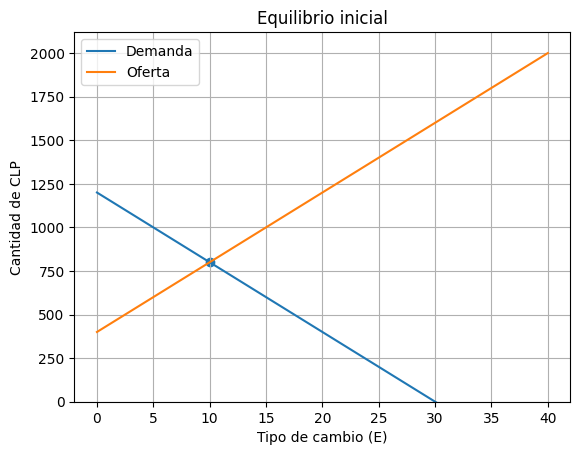


Nuevo equilibrio:
Tipo de cambio(E): 15.0
Cantidad de CLP: 800.0


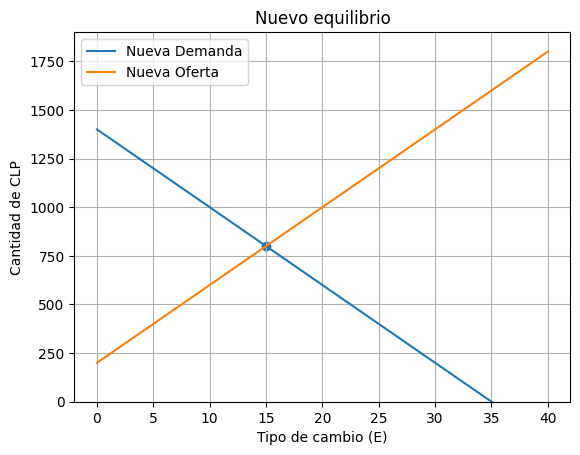

In [45]:
import numpy as np
import matplotlib.pyplot as plt

E = np.linspace(0, 40, 100)
Md = 1200 - 40*E
Ms = 400 + 40*E

# Equilibrio
E_eq = (1200 - 400) / (80) # despeje de la igualdad para encontrar el equilibrio (E)
Ms_eq = 400 + 40*E_eq # reemplazando E en la oferta para encontrar la cantidad de CLP

print("Equilibrio inicial:")
print("Tipo de cambio(E):", E_eq)
print("Cantidad de CLP:", Ms_eq)

plt.figure()
plt.plot(E, Md, label='Demanda')
plt.plot(E, Ms, label='Oferta')
plt.scatter(E_eq, Ms_eq)
plt.title("Equilibrio inicial")
plt.xlabel("Tipo de cambio (E)")
plt.ylabel("Cantidad de CLP")
plt.legend()
plt.grid()
plt.ylim(0, None)
plt.show()

# Nuevo equilibrio
Md2 = 1400 - 40*E
Ms2 = 200 + 40*E

E_eq2 = (1400 - 200) / (80)
Ms_eq2 = 200 + 40*E_eq2

print("\nNuevo equilibrio:")
print("Tipo de cambio(E):", E_eq2)
print("Cantidad de CLP:", Ms_eq2)

# Gráfico
plt.figure()
plt.plot(E, Md2, label='Nueva Demanda')
plt.plot(E, Ms2, label='Nueva Oferta')
plt.scatter(E_eq2, Ms_eq2)
plt.title("Nuevo equilibrio")
plt.xlabel("Tipo de cambio (E)")
plt.ylabel("Cantidad de CLP")
plt.legend()
plt.grid()
plt.ylim(0, None)
plt.show()

Podemos observar un aumento en el tipo de cambio de equilibrio desde 10 a 15 CLP/USD, lo que implica una depreciación del peso chileno frente al dólar. Esto se explica debido a la  expansión monetaria en Estados Unidos y una política contractiva en Chile, el resultado demuestra como el equilibrio tipo de cambio se ve afectado tanto por factores tanto externos como internos. Por un lado, la mayor disponibilidad de dólares a nivel internacional aumenta la demanda de monedas extranjeras; por otro, el alza en la tasa de interés local reduce la liquidez interna y atrae capitales financieros, reforzando los flujos hacia la economía chilena. A pesar de que ambos efectos podrían interpretarse como favorables para el peso chileno, el resultado final muestra una depreciación, lo que sugiere que el impacto conjunto de estos shocks termina siento contraproducente. Este resultado pone en evidencia que el tipo de cambio está expuesto múltiples fuerzas que podrian tener efectos adversos en el. En términos económicos, una depreciación bajo este contexto puede generar efectos mixtos: por un lado, mejora la competitividad externa, pero por otro, encarece las importaciones y puede amplificar presiones inflacionarias.